<a href="https://colab.research.google.com/github/esalramo94/TELECOM-X1/blob/main/Procesado_de_datos.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Importar la librería necesaria
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# Definir el enlace de la API/GitHub
url_api = "https://raw.githubusercontent.com/ingridcristh/challenge2-data-science-LATAM/main/TelecomX_Data.json"

In [ ]:
# Cargar los datos desde la URL
df_telecom = pd.read_json(url_api)

# Mostrar las primeras 5 filas para verificar que se cargó correctamente
display(df_telecom.head())

,customerID,Churn,customer,phone,internet,account
0,0002-ORFBO,No,"{'gender': 'Female', 'SeniorCitizen': 0, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'One year', 'PaperlessBilling': '..."
1,0003-MKNFE,No,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'Yes'}","{'InternetService': 'DSL', 'OnlineSecurity': '...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
2,0004-TLHLJ,Yes,"{'gender': 'Male', 'SeniorCitizen': 0, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
3,0011-IGKFF,Yes,"{'gender': 'Male', 'SeniorCitizen': 1, 'Partne...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."
4,0013-EXCHZ,Yes,"{'gender': 'Female', 'SeniorCitizen': 1, 'Part...","{'PhoneService': 'Yes', 'MultipleLines': 'No'}","{'InternetService': 'Fiber optic', 'OnlineSecu...","{'Contract': 'Month-to-month', 'PaperlessBilli..."


In [ ]:
df_telecom.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


In [ ]:
df_telecom.dtypes

,0
customerID,object
Churn,object
customer,object
phone,object
internet,object
account,object


In [ ]:
# 1. Definimos las columnas que tienen diccionarios ocultos
columnas_anidadas = ['customer', 'phone', 'internet', 'account']

# 2. Extraemos cada diccionario en nuevas columnas y las unimos al DataFrame
for col in columnas_anidadas:
    # Expandimos el diccionario en nuevas columnas (ej. 'gender', 'SeniorCitizen')
    df_expandido = df_telecom[col].apply(pd.Series)

    # Unimos las nuevas columnas al DataFrame original
    df_telecom = pd.concat([df_telecom, df_expandido], axis=1)

    # Eliminamos la columna original que ya no nos sirve
    df_telecom = df_telecom.drop(col, axis=1)

# Verificamos cómo quedó el DataFrame "plano"
display(df_telecom.head())

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Charges
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,No,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,"{'Monthly': 65.6, 'Total': '593.3'}"
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,No,Mailed check,"{'Monthly': 59.9, 'Total': '542.4'}"
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,"{'Monthly': 73.9, 'Total': '280.85'}"
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,"{'Monthly': 98.0, 'Total': '1237.85'}"
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,No,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,"{'Monthly': 83.9, 'Total': '267.4'}"


In [ ]:
# 1. Filtrar el DataFrame para mantener solo filas donde Churn sea 'Yes' o 'No'
# Esto elimina automáticamente nulos, vacíos o valores extraños
df_telecom = df_telecom[df_telecom['Churn'].isin(['Yes', 'No'])].copy()

# 2. (Opcional) Si quieres estandarizar a minúsculas o mayúsculas, podrías usar:
# df_telecom['Churn'] = df_telecom['Churn'].str.capitalize()

# Verificamos que solo existan dos categorías
print("Categorías en Churn tras la limpieza:", df_telecom['Churn'].unique())

Categorías en Churn tras la limpieza: ['No' 'Yes']


In [ ]:
# 1. Expandir la columna 'charges' que quedó como diccionario
df_charges = df_telecom['Charges'].apply(pd.Series)

# 2. Unir las nuevas columnas (Monthly, Total, etc.) al DataFrame original
df_telecom = pd.concat([df_telecom, df_charges], axis=1)

# 3. Eliminar la columna 'charges' original para limpiar el DataFrame
df_telecom = df_telecom.drop('Charges', axis=1)

# 4. Ver el resultado final y los tipos de datos
print(df_telecom.info())
display(df_telecom.head())

<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   int64  
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 
 17  

,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,Monthly,Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [ ]:
# --- 1. Revisar los tipos de datos (buscar inconsistencias) ---
print("Tipos de datos por columna:")
print(df_telecom.info())
print("-" * 40)



Tipos de datos por columna:
<class 'pandas.core.frame.DataFrame'>
Index: 7043 entries, 0 to 7266
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   Churn             7043 non-null   object 
 2   gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   int64  
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7

In [ ]:
# --- 2. Buscar valores nulos (ausentes) ---
print("\nValores nulos por columna:")
print(df_telecom.isnull().sum())
print("-" * 40)




Valores nulos por columna:
customerID          0
Churn               0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
Monthly             0
Total               0
dtype: int64
----------------------------------------


In [ ]:
# --- 3. Buscar filas exactamente duplicadas ---
duplicados = df_telecom.duplicated().sum()
print(f"\nNúmero de filas duplicadas: {duplicados}")


Número de filas duplicadas: 0


In [ ]:
# 1. Identificar la columna de cargos mensuales (ajusta el nombre si es necesario, ej: 'monthly')
# Convertimos a numérico por seguridad
df_telecom['monthly'] = pd.to_numeric(df_telecom['Monthly'], errors='coerce')

# 2. Crear la columna 'Cuentas_Diarias'
# Usamos un promedio de 30 días para la facturación diaria
df_telecom['Cuentas_Diarias'] = df_telecom['Monthly'] / 30

# 3. Redondear a 2 decimales para que sea legible
df_telecom['Cuentas_Diarias'] = df_telecom['Cuentas_Diarias'].round(2)

# 4. Ver los resultados
display(df_telecom[['customerID', 'Monthly', 'Cuentas_Diarias']].head())

,customerID,Monthly,Cuentas_Diarias
0,0002-ORFBO,65.6,2.19
1,0003-MKNFE,59.9,2.00
2,0004-TLHLJ,73.9,2.46
3,0011-IGKFF,98.0,3.27
4,0013-EXCHZ,83.9,2.80


In [ ]:
# Seleccionamos las columnas numéricas relevantes
cols_numericas = ['Monthly', 'Total', 'Cuentas_Diarias']

# Aseguramos que todas sean numéricas (por si acaso quedaron como texto)
for col in cols_numericas:
    df_telecom[col] = pd.to_numeric(df_telecom[col], errors='coerce')

# Generar el reporte estadístico
analisis_stats = df_telecom[cols_numericas].describe()

# Añadir la mediana explícitamente (el 50% del describe es la mediana, pero aquí la resaltamos)
print("--- Análisis Descriptivo de Cargos ---")
display(analisis_stats)

--- Análisis Descriptivo de Cargos ---


,Monthly,Total,Cuentas_Diarias
count,7043.000000,7032.000000,7043.000000
mean,64.761692,2283.300441,2.158675
std,30.090047,2266.771362,1.003088
min,18.250000,18.800000,0.610000
25%,35.500000,401.450000,1.180000
50%,70.350000,1397.475000,2.340000
75%,89.850000,3794.737500,2.990000
max,118.750000,8684.800000,3.960000


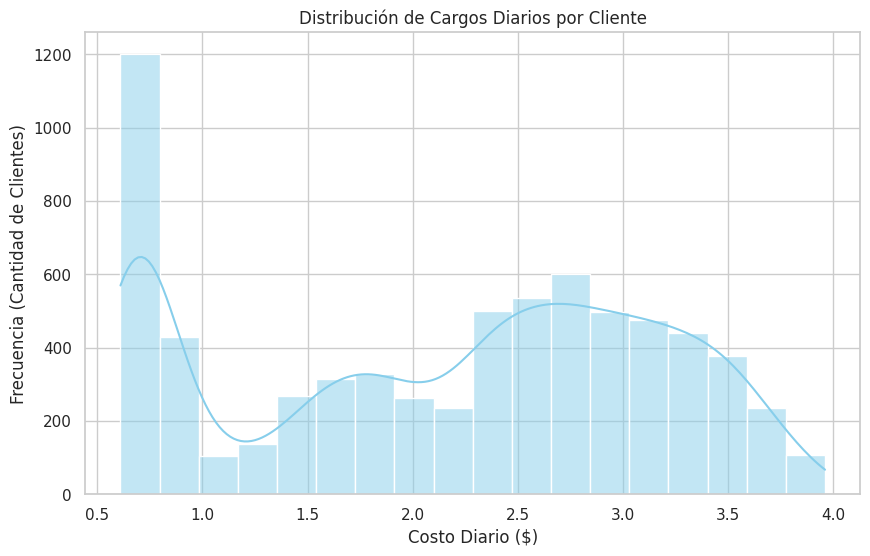

In [ ]:


plt.figure(figsize=(10, 6))
sns.histplot(df_telecom['Cuentas_Diarias'], kde=True, color='skyblue')
plt.title('Distribución de Cargos Diarios por Cliente')
plt.xlabel('Costo Diario ($)')
plt.ylabel('Frecuencia (Cantidad de Clientes)')
plt.show()

In [ ]:
# Ver la proporción de Evasión (Churn)
print("--- Proporción de Evasión (Churn) ---")
print(df_telecom['Churn'].value_counts(normalize=True) * 100)

# Ver tipos de contrato predominantes
print("\n--- Tipos de Contrato ---")
# Nota: Ajusta el nombre 'contract' si quedó diferente tras la expansión
print(df_telecom['Contract'].value_counts())

--- Proporción de Evasión (Churn) ---
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

--- Tipos de Contrato ---
Contract
Month-to-month    3875
Two year          1695
One year          1473
Name: count, dtype: int64


/tmp/ipykernel_378/1782286407.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Churn', data=df_telecom, ax=ax[0], palette='viridis', order=['No', 'Yes'])


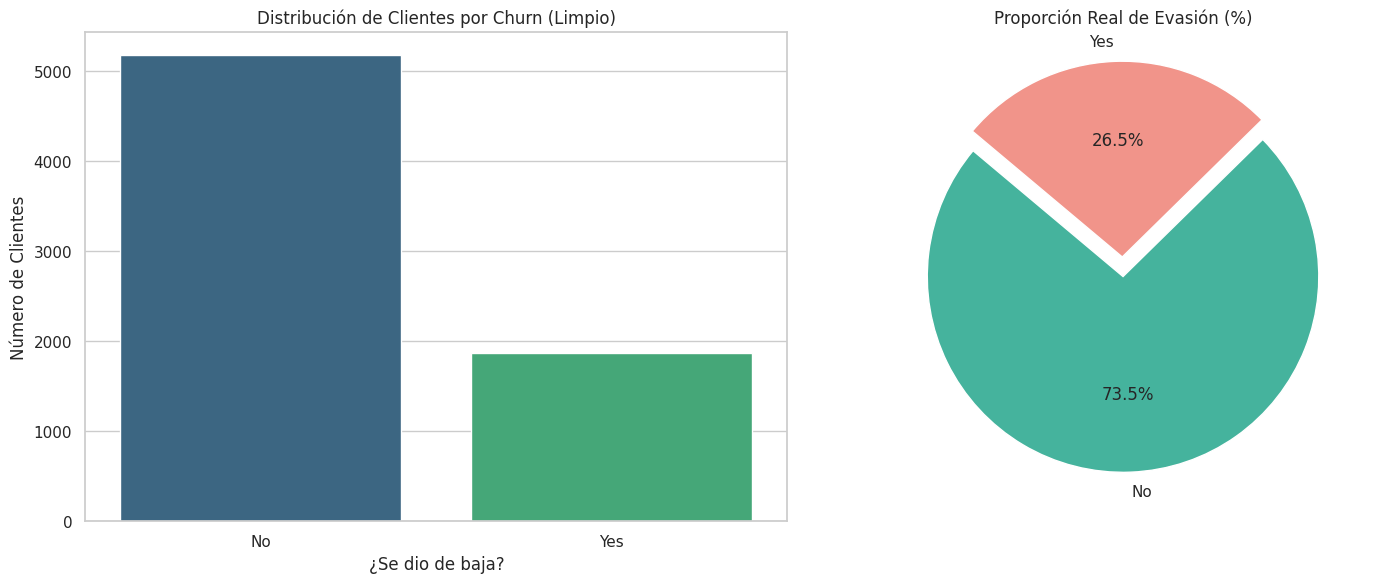

In [ ]:
# Recalcular conteos tras la limpieza
churn_counts = df_telecom['Churn'].value_counts()

# Configuración de estilo
sns.set_theme(style="whitegrid")
fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# 1. Gráfico de Barras
sns.countplot(x='Churn', data=df_telecom, ax=ax[0], palette='viridis', order=['No', 'Yes'])
ax[0].set_title('Distribución de Clientes por Churn (Limpio)')
ax[0].set_xlabel('¿Se dio de baja?')
ax[0].set_ylabel('Número de Clientes')

# 2. Gráfico de Pastel
n_categorias = len(churn_counts)
explode = [0.1 if index == 'Yes' else 0 for index in churn_counts.index]

ax[1].pie(churn_counts,
          labels=churn_counts.index,
          autopct='%1.1f%%',
          colors=['#45B39D', '#F1948A'], # Colores fijos para No y Yes
          startangle=140,
          explode=explode)
ax[1].set_title('Proporción Real de Evasión (%)')

plt.tight_layout()
plt.show()

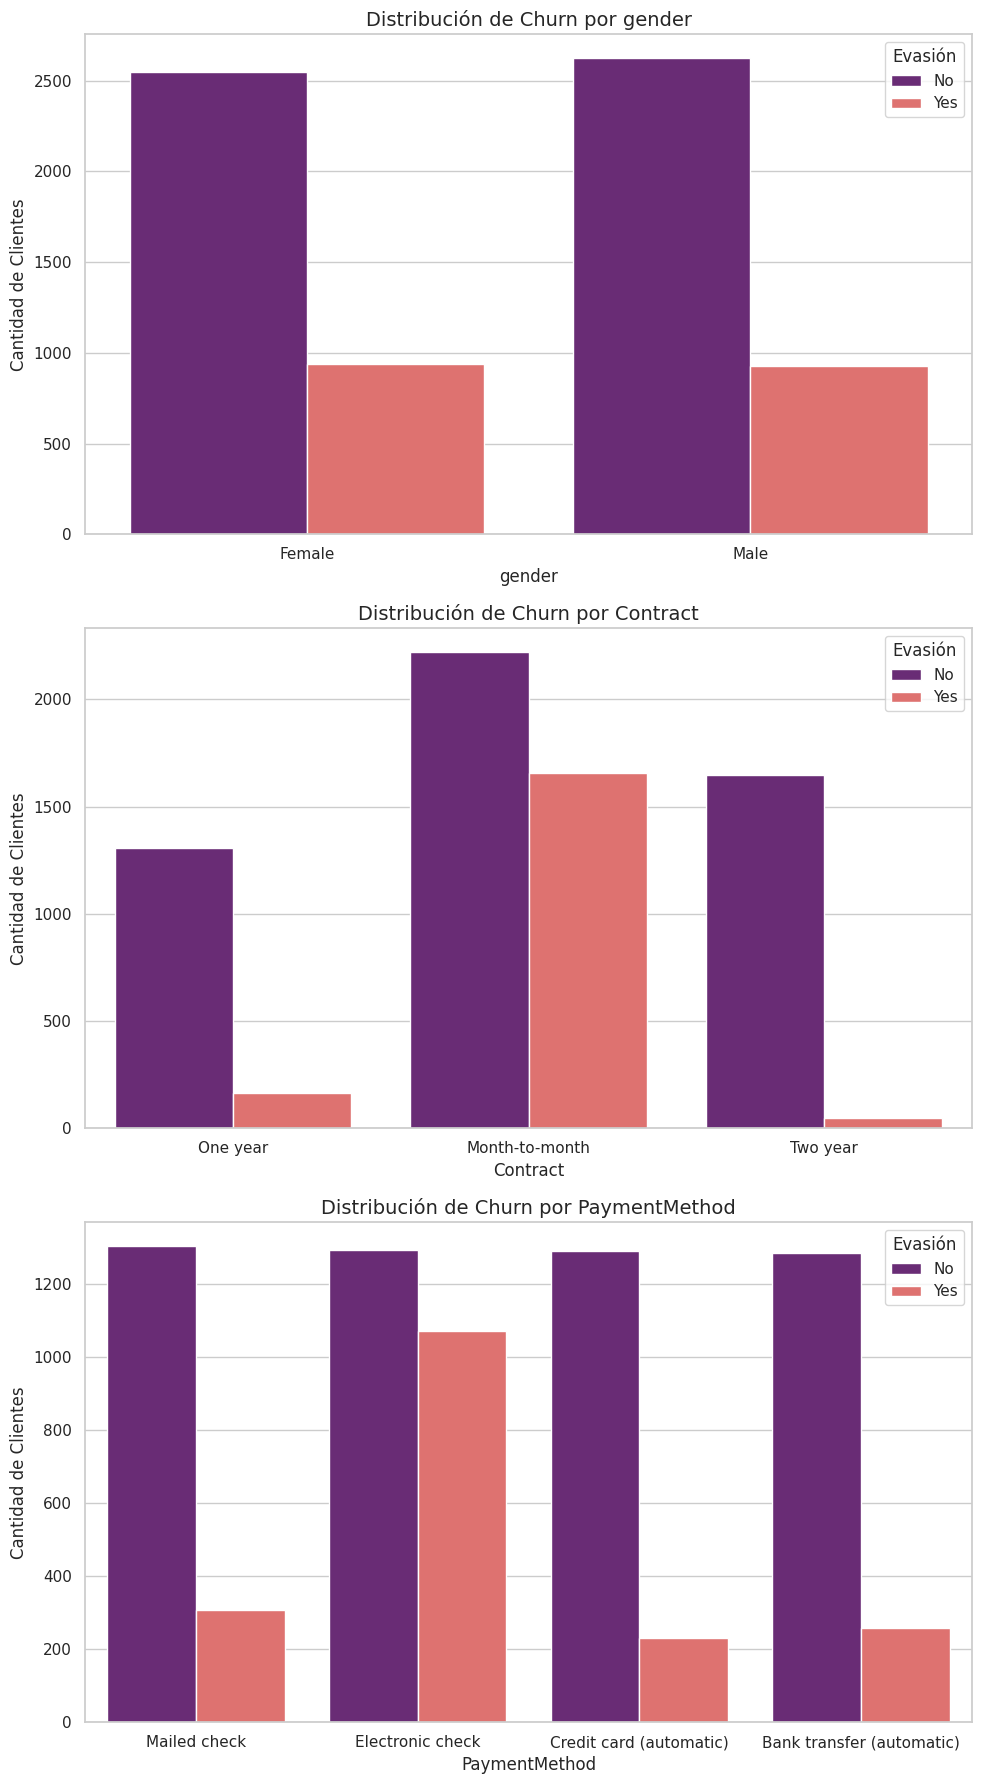

In [ ]:
# Lista de variables a analizar
variables_cat = ['gender', 'Contract', 'PaymentMethod']

# Configuración de la figura
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(10, 18))

for i, col in enumerate(variables_cat):
    # Crear gráfico de barras segmentado
    sns.countplot(x=col, hue='Churn', data=df_telecom, ax=axes[i], palette='magma')

    axes[i].set_title(f'Distribución de Churn por {col}', fontsize=14)
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Cantidad de Clientes')
    axes[i].legend(title='Evasión', loc='upper right')

plt.tight_layout()
plt.show()

/tmp/ipykernel_378/1960639159.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=df_telecom, palette='Set2')
/tmp/ipykernel_378/1960639159.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=df_telecom, palette='Set2')
/tmp/ipykernel_378/1960639159.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=df_telecom, palette='Set2')


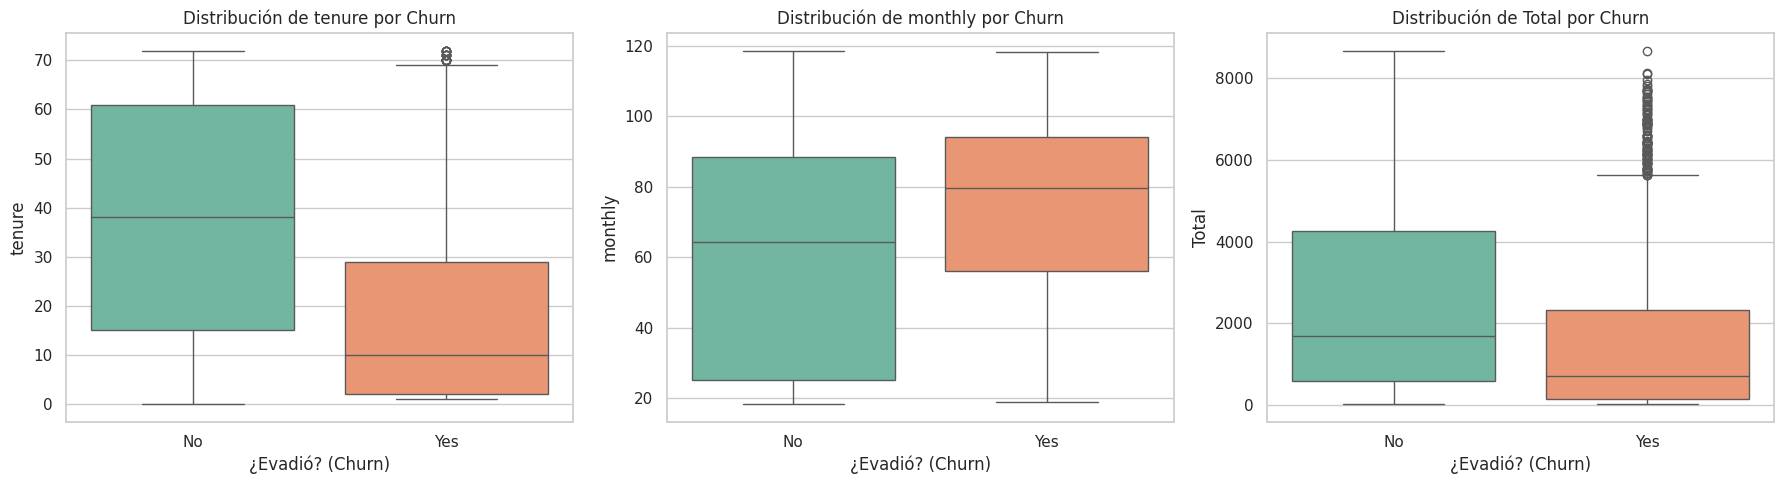

In [ ]:
# Lista de variables numéricas a comparar con Churn
vars_numericas = ['tenure', 'monthly', 'Total']

# Configuración de la figura
plt.figure(figsize=(18, 5))

for i, col in enumerate(vars_numericas):
    plt.subplot(1, 3, i+1)
    sns.boxplot(x='Churn', y=col, data=df_telecom, palette='Set2')
    plt.title(f'Distribución de {col} por Churn')
    plt.xlabel('¿Evadió? (Churn)')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

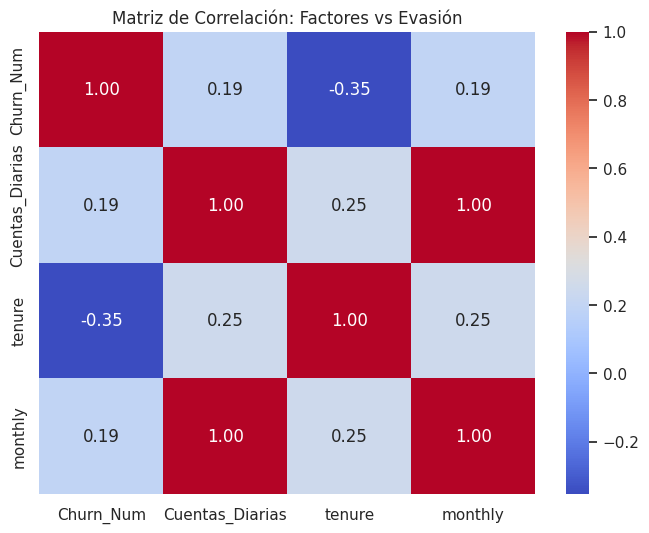

In [ ]:
# Crear una copia para no alterar el dataframe original de reporte
df_corr = df_telecom.copy()

# Convertir Churn a numérico: Yes=1, No=0
df_corr['Churn_Num'] = df_corr['Churn'].map({'Yes': 1, 'No': 0})

# Seleccionar variables numéricas para la matriz
columnas_analisis = ['Churn_Num', 'Cuentas_Diarias', 'tenure', 'monthly']
matriz_corr = df_corr[columnas_analisis].corr()

# Visualizar con un Mapa de Calor (Heatmap)
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.heatmap(matriz_corr, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Matriz de Correlación: Factores vs Evasión')
plt.show()

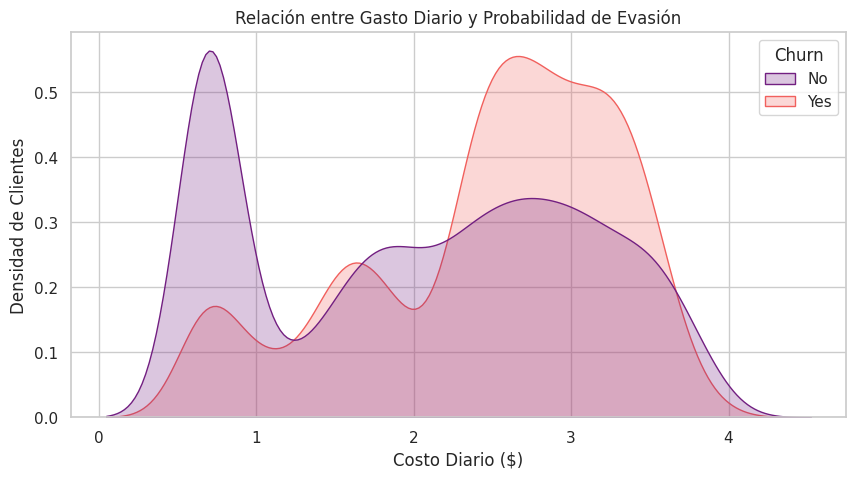

In [ ]:
plt.figure(figsize=(10, 5))
sns.kdeplot(data=df_corr, x='Cuentas_Diarias', hue='Churn', fill=True, common_norm=False, palette='magma')
plt.title('Relación entre Gasto Diario y Probabilidad de Evasión')
plt.xlabel('Costo Diario ($)')
plt.ylabel('Densidad de Clientes')
plt.show()

/tmp/ipykernel_378/2403792406.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Total_Servicios', y='Churn_Num', data=df_corr, palette='Blues_d')


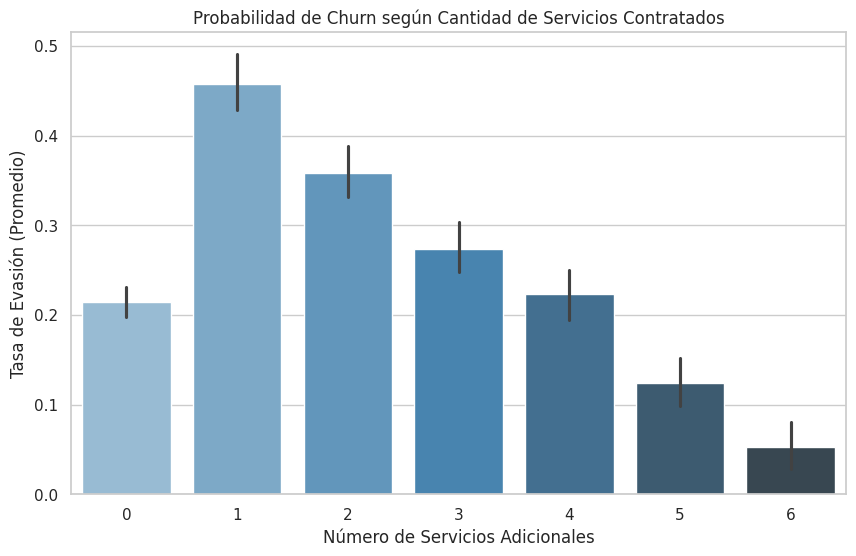

In [ ]:
# Lista de columnas de servicios (ajusta según los nombres que quedaron en tu dataframe)
servicios = ['OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies']

# Contar cuántos 'Yes' tiene cada cliente en esas columnas
df_corr['Total_Servicios'] = df_corr[servicios].apply(lambda x: (x == 'Yes').sum(), axis=1)

# Visualizar la relación
plt.figure(figsize=(10, 6))
sns.barplot(x='Total_Servicios', y='Churn_Num', data=df_corr, palette='Blues_d')
plt.title('Probabilidad de Churn según Cantidad de Servicios Contratados')
plt.ylabel('Tasa de Evasión (Promedio)')
plt.xlabel('Número de Servicios Adicionales')
plt.show()